In [4]:
import pandas as pd
import numpy as np
import json
import os
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
# Load all attention CSV, predctions and bag_labels

model_output_dir = "/home/ubuntu/giodir/digitalPathology/aiflopp/outputs/merged_RT/binary_diff_first"
predictions_dir = "/home/ubuntu/giodir/digitalPathology/aiflopp/outputs_inference/mergedRT_bin_diff_first"

# Load all attention scores for each bag
attn_score_dir = f"{predictions_dir}/attention_scores"
attention_scores = {}
for file in os.listdir(attn_score_dir):
    if file.endswith(".csv"):
        bag_id = file.replace(".csv", "")
        df = pd.read_csv(os.path.join(attn_score_dir, file))
        attention_scores[bag_id] = df

# Load predictions and bag labels
predictions_gt_path = f"{predictions_dir}/predictions.csv"
pred_gt_df = pd.read_csv(predictions_gt_path)

# Check ids between attention scores and predictions
attn_ids = set(attention_scores.keys())
pred_ids = set(pred_gt_df["bag_id"].astype(str))
print(f"Attention score bag ids: {len(attn_ids)}")
print(f"Prediction bag ids: {len(pred_ids)}")

if attn_ids != pred_ids:
    print("Warning: Mismatch in bag ids between attention scores and predictions")
    print(f"Only in attention scores: {attn_ids - pred_ids}")
    print(f"Only in predictions: {pred_ids - attn_ids}")


Attention score bag ids: 154
Prediction bag ids: 154


/tmp/ipykernel_254609/2400926266.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(positive_attn_scores, label="Discordance Bags", shade=True, log_scale=True)
/tmp/ipykernel_254609/2400926266.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(negative_attn_scores, label="Accordance Bags", shade=True, log_scale=True)


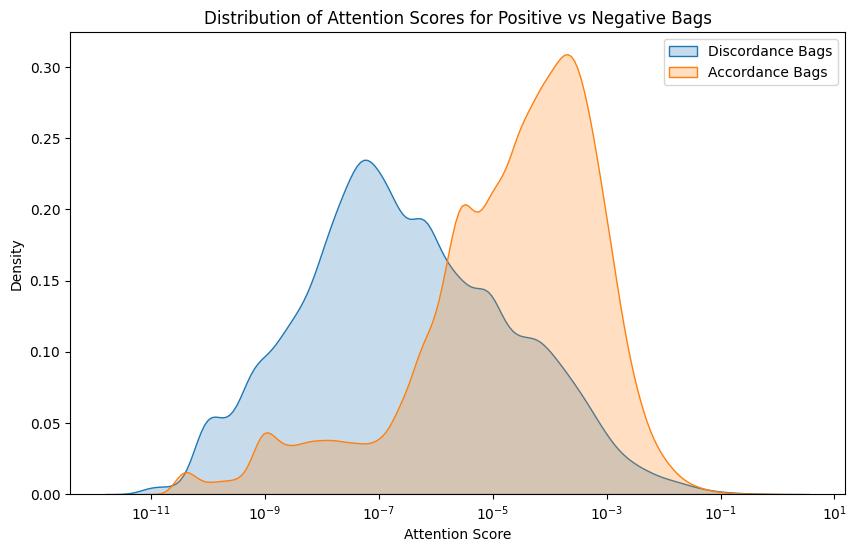

In [ ]:
positive_bag_ids = pred_gt_df[pred_gt_df["label"] == 1]["bag_id"].astype(str).tolist()
negative_bag_ids = pred_gt_df[pred_gt_df["label"] == 0]["bag_id"].astype(str).tolist()

positive_attn_scores = []
negative_attn_scores = []

for bag_id in positive_bag_ids:
    df = attention_scores[bag_id]
    positive_attn_scores.extend(df["attention_score"].tolist())
for bag_id in negative_bag_ids:
    df = attention_scores[bag_id]
    negative_attn_scores.extend(df["attention_score"].tolist())

# Plot the distributions of attention scores for positive and negative bags

plt.figure(figsize=(10, 6))
sns.kdeplot(positive_attn_scores, label="Discordance Bags", shade=True, log_scale=True)
sns.kdeplot(negative_attn_scores, label="Accordance Bags", shade=True, log_scale=True)
plt.title("Distribution of Attention Scores for Discordance vs Accordance Bags")
plt.xlabel("Attention Score")
plt.ylabel("Density")
plt.legend()
plt.show()


/tmp/ipykernel_254609/3958004700.py:20: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(positive_entropies, label="Discordance Bags", shade=True)
/tmp/ipykernel_254609/3958004700.py:21: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(negative_entropies, label="Accordance Bags", shade=True)


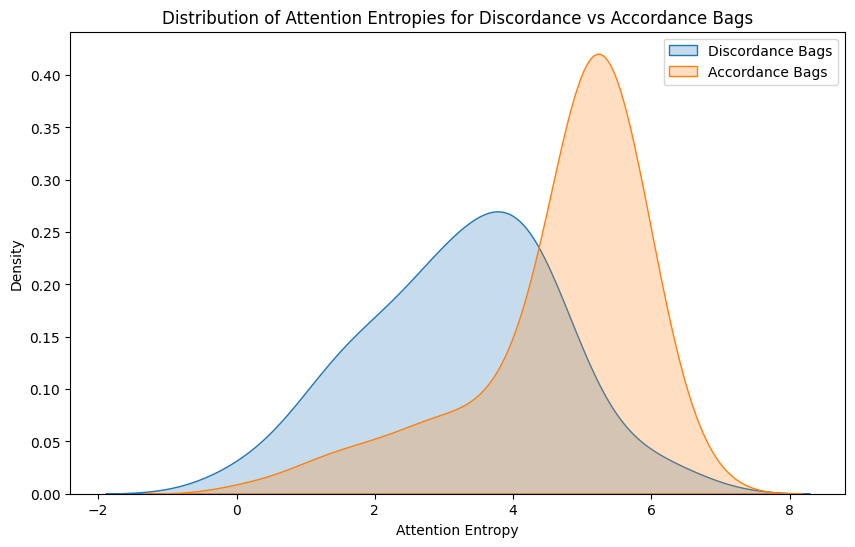

In [11]:
# Comput bags entropy and compare between positive and negative bags
def compute_entropy(attn_scores):
    attn_scores = np.array(attn_scores)
    #attn_scores = attn_scores / np.sum(attn_scores)  # Normalize to get probabilities
    entropy = -np.sum(attn_scores * np.log(attn_scores + 1e-10))  # Add small value to avoid log(0)
    return entropy

positive_entropies = []
negative_entropies = []
for bag_id in positive_bag_ids:
    df = attention_scores[bag_id]
    entropy = compute_entropy(df["attention_score"].tolist())
    positive_entropies.append(entropy)
for bag_id in negative_bag_ids:
    df = attention_scores[bag_id]
    entropy = compute_entropy(df["attention_score"].tolist())
    negative_entropies.append(entropy)

plt.figure(figsize=(10, 6))
sns.kdeplot(positive_entropies, label="Discordance Bags", shade=True)
sns.kdeplot(negative_entropies, label="Accordance Bags", shade=True)
plt.title("Distribution of Attention Entropies for Discordance vs Accordance Bags")
plt.xlabel("Attention Entropy")
plt.ylabel("Density")
plt.legend()
plt.show()